Carga de datos

In [2]:
import pandas as pd
import io
from google.colab import files

# 1. Cargar archivo
uploaded = files.upload()

# 2. Lectura a Dataframe
nombre_archivo = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nombre_archivo]))

# 3. Verificacion
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

df.info()

print("\nDistribución de la variable objetivo:")
print(df['Evasion'].value_counts(normalize=True) * 100)

Saving datos_telecom_limpios.csv to datos_telecom_limpios.csv
Dimensiones del dataset: 7043 filas y 22 columnas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID_Cliente                 7043 non-null   object 
 1   Evasion                    7043 non-null   int64  
 2   Genero                     7043 non-null   object 
 3   Adulto_Mayor               7043 non-null   int64  
 4   Tiene_Pareja               7043 non-null   int64  
 5   Tiene_Dependientes         7043 non-null   int64  
 6   Meses_Permanencia          7043 non-null   int64  
 7   Servicio_Telefonico        7043 non-null   int64  
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   obje

Eliminacion de columnas irrelevantes

In [3]:
#Crear copia para mantener la integridad original de los datos
df_modelo = df.copy()

#Definir columnas irrelevantes
columnas_irrelevantes = ['ID_Cliente', 'Cargos_Diarios']

# Eliminamos las columnas
df_modelo = df_modelo.drop(columns=columnas_irrelevantes)

Encoding

In [4]:
df_final_ml = pd.get_dummies(df_modelo, drop_first=True)

df_final_ml.head()

,Evasion,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Cargos_Mensuales,Cargos_Totales,Genero_male,phone.MultipleLines_no phone service,...,internet.StreamingTV_no internet service,internet.StreamingTV_yes,internet.StreamingMovies_no internet service,internet.StreamingMovies_yes,Tipo_Contrato_one year,Tipo_Contrato_two year,account.PaperlessBilling_yes,account.PaymentMethod_credit card (automatic),account.PaymentMethod_electronic check,account.PaymentMethod_mailed check
0,0,0,1,1,9,1,65.6,593.30,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0,0,0,0,9,1,59.9,542.40,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1,0,0,0,4,1,73.9,280.85,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,1,1,0,13,1,98.0,1237.85,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,1,1,0,3,1,83.9,267.40,False,False,...,False,True,False,False,False,False,True,False,False,True


Verificación de la Proporción de Cancelación (Churn)

In [5]:
# Contar clientes: 0 = No se fue, 1 = Se fue
conteo_clases = df_final_ml['Evasion'].value_counts()
proporcion_clases = df_final_ml['Evasion'].value_counts(normalize=True) * 100

print("Conteo absoluto de clientes:")
print(conteo_clases)

print("\nProporción porcentual:")
print(proporcion_clases)



Conteo absoluto de clientes:
Evasion
0    5174
1    1869
Name: count, dtype: int64

Proporción porcentual:
Evasion
0    73.463013
1    26.536987
Name: proportion, dtype: float64


Graficas

/tmp/ipykernel_327/1979821096.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Evasion', data=df_final_ml, palette='viridis')


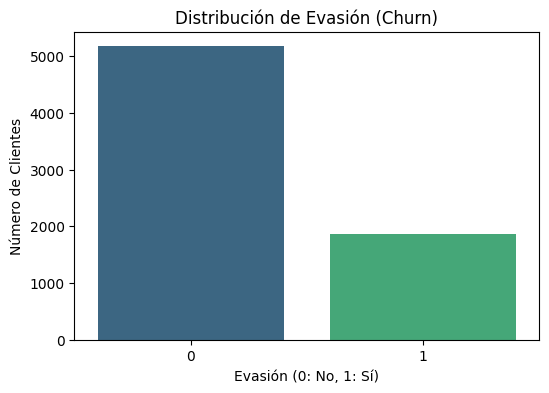

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Evasion', data=df_final_ml, palette='viridis')
plt.title('Distribución de Evasión (Churn)')
plt.xlabel('Evasión (0: No, 1: Sí)')
plt.ylabel('Número de Clientes')
plt.show()

Balanceo de Clases

In [9]:
from imblearn.over_sampling import SMOTE

X = df_final_ml.drop('Evasion', axis=1)
y = df_final_ml['Evasion']

# Configurar SMOTE
smt = SMOTE(random_state=42)

# Aplicar balanceo
X_res, y_res = smt.fit_resample(X, y)

# Verificar nuevo balance
print("Distribución después de SMOTE:")
print(y_res.value_counts(normalize=True) * 100)

Distribución después de SMOTE:
Evasion
0    50.0
1    50.0
Name: proportion, dtype: float64


Normalización o Estandarización